# MODIS Snow Preprocessing Notebook
This notebook preprocesses MODIS/Terra Snow Cover Daily L3 Global 500m SIN Grid V061 for 2024, clips the snow raster to the `aoi_gb_north_kpk_ajk.geojson` boundary, and writes Cloud-Optimized GeoTIFF outputs and derived summary products.

In [1]:
from pathlib import Path

root = Path.cwd()
snow_dir = (root.parent / 'snow_data' / 'MOD10A1_61-20260412_161448').resolve()
aoi_path = (root / 'sds' / 'aoi_gb_north_kpk_ajk.geojson').resolve()
output_cog_dir = (root / 'outputs' / 'snow_cogs').resolve()
output_summary_dir = (root / 'outputs' / 'snow_summary').resolve()
output_cog_dir.mkdir(parents=True, exist_ok=True)
output_summary_dir.mkdir(parents=True, exist_ok=True)

hdf_files = sorted(snow_dir.glob('*.hdf'))
print('Notebook root:', root)
print('Snow source folder:', snow_dir)
print('AOI path:', aoi_path, 'exists:', aoi_path.exists())
print('COG output folder:', output_cog_dir)
print('Summary output folder:', output_summary_dir)
print('HDF count:', len(hdf_files))
print('Sample HDF:', hdf_files[0] if hdf_files else None)

Notebook root: c:\Users\AtifA\Desktop\Wasif SDS Project\sds
Snow source folder: C:\Users\AtifA\Desktop\Wasif SDS Project\snow_data\MOD10A1_61-20260412_161448
AOI path: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\aoi_gb_north_kpk_ajk.geojson exists: True
COG output folder: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_cogs
Summary output folder: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_summary
HDF count: 732
Sample HDF: C:\Users\AtifA\Desktop\Wasif SDS Project\snow_data\MOD10A1_61-20260412_161448\MOD10A1.A2024001.h23v05.061.2024004183105.hdf


In [2]:
import shutil
print('conda path', shutil.which('conda'))

conda path C:\Users\AtifA\miniconda3\Scripts\conda.EXE


In [3]:
import geopandas as gpd

aoi = gpd.read_file(aoi_path)
print('AOI CRS:', aoi.crs)
print('Number of features:', len(aoi))
print('AOI bounds:', aoi.total_bounds)
aoi = aoi.to_crs(epsg=32643)
print('AOI bounds in EPSG:32643:', aoi.total_bounds)

AOI CRS: EPSG:32643
Number of features: 1
AOI bounds: [ 131981.61696435 3625653.49548206  744155.66673087 4105739.32377728]
AOI bounds in EPSG:32643: [ 131981.61696435 3625653.49548206  744155.66673087 4105739.32377728]


In [9]:
from osgeo import gdal

hdf_path = hdf_files[0]
print('HDF path:', hdf_path)

hdf_path_text = str(hdf_path).replace('\\', '/')
subdataset = f'HDF4_EOS:EOS_GRID:"{hdf_path_text}":MOD_Grid_Snow_500m:NDSI_Snow_Cover'
print('Trying subdataset path:', subdataset)

ds = gdal.Open(subdataset)
if ds is None:
    raise RuntimeError(f'Unable to open subdataset: {subdataset}')
print('Opened subdataset')
print('size', ds.RasterXSize, ds.RasterYSize)
print('projection', ds.GetProjectionRef())
print('geotransform', ds.GetGeoTransform())

HDF path: C:\Users\AtifA\Desktop\Wasif SDS Project\snow_data\MOD10A1_61-20260412_161448\MOD10A1.A2024001.h23v05.061.2024004183105.hdf
Trying subdataset path: HDF4_EOS:EOS_GRID:"C:/Users/AtifA/Desktop/Wasif SDS Project/snow_data/MOD10A1_61-20260412_161448/MOD10A1.A2024001.h23v05.061.2024004183105.hdf":MOD_Grid_Snow_500m:NDSI_Snow_Cover
subdataset open failed: RasterioIOError 'HDF4_EOS:EOS_GRID:"C:/Users/AtifA/Desktop/Wasif SDS Project/snow_data/MOD10A1_61-20260412_161448/MOD10A1.A2024001.h23v05.061.2024004183105.hdf":MOD_Grid_Snow_500m:NDSI_Snow_Cover' does not exist in the file system, and is not recognized as a supported dataset name.
direct open failed: RasterioIOError 'C:\Users\AtifA\Desktop\Wasif SDS Project\snow_data\MOD10A1_61-20260412_161448\MOD10A1.A2024001.h23v05.061.2024004183105.hdf' not recognized as being in a supported file format.


In [7]:
import subprocess
cmd = ['conda', 'install', '-n', 'sds', '-c', 'conda-forge', 'gdal', 'pyhdf', 'libgdal-hdf4', '-y']
print('Installing packages:', ' '.join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print('returncode', result.returncode)
print(result.stdout[-4000:])
print(result.stderr[-4000:])

Installing packages: conda install -n sds -c conda-forge gdal pyhdf libgdal-hdf4 -y
returncode 0
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\AtifA\miniconda3\envs\sds

  added / updated specs:
    - gdal
    - libgdal-hdf4
    - pyhdf


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    libaec-1.1.5               |       haf901d7_0          34 KB  conda-forge
    libgdal-hdf4-3.12.3        |       h5bd48a5_0         553 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         587 KB

The following NEW packages will be INSTALLED:

  libaec             conda-forge/win-64::libaec-1.1.5-haf901d7_0 
  libgdal-hdf4       conda-forge/win-64::libgdal-hdf4-3.12.3-h5bd48a5_0 



libgdal-hdf4-3.12

In [24]:
import numpy as np
import xarray as xr
import rioxarray
import pandas as pd
from collections import defaultdict
from osgeo import gdal
from tqdm import tqdm


def get_modis_subdataset(hdf_path):
    hdf_path_text = str(hdf_path).replace('\\', '/')
    return f'HDF4_EOS:EOS_GRID:"{hdf_path_text}":MOD_Grid_Snow_500m:NDSI_Snow_Cover'


def write_clipped_cog(hdf_path, out_path, aoi_geojson, nodata=255):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    subds = get_modis_subdataset(hdf_path)
    warp_options = gdal.WarpOptions(
        format='COG',
        cutlineDSName=str(aoi_geojson),
        cropToCutline=True,
        dstNodata=nodata,
        creationOptions=['COMPRESS=DEFLATE', 'BLOCKSIZE=512'],
    )
    ds = gdal.Warp(str(out_path), subds, options=warp_options)
    if ds is None:
        raise RuntimeError(f'Warp failed for {hdf_path}')
    ds = None
    return out_path


def merge_daily_parts(part_paths, out_path, aoi_geojson, nodata=255):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    warp_options = gdal.WarpOptions(
        format='COG',
        cutlineDSName=str(aoi_geojson),
        cropToCutline=True,
        dstNodata=nodata,
        creationOptions=['COMPRESS=DEFLATE', 'BLOCKSIZE=512'],
    )
    ds = gdal.Warp(str(out_path), [str(p) for p in part_paths], options=warp_options)
    if ds is None:
        raise RuntimeError(f'Merge failed for {out_path}')
    ds = None
    return out_path


def get_hdf_date(hdf_path):
    return hdf_path.stem.split('.')[1][1:]


def get_hdf_tile(hdf_path):
    return hdf_path.stem.split('.')[2]


def build_summary_from_cogs(cog_paths, out_dir):
    stack = []
    dates = []
    for path in cog_paths:
        da = rioxarray.open_rasterio(str(path), masked=True).squeeze('band', drop=True)
        stack.append(da)
        dates.append(pd.to_datetime(path.stem.split('_')[1], format='%Y%j'))

    combined = xr.concat(stack, dim='time')
    combined = combined.assign_coords(time=('time', dates))
    combined.rio.write_crs(combined.rio.crs, inplace=True)
    snow_mask = (combined > 0) & (combined <= 100)
    snow_days = snow_mask.sum(dim='time')
    valid_count = combined.notnull().sum(dim='time')
    snow_frequency = snow_days / valid_count
    snow_days.rio.to_raster(out_dir / 'snow_days.tif', driver='COG', compress='DEFLATE', blocksize=512)
    snow_frequency.rio.to_raster(out_dir / 'snow_frequency.tif', driver='COG', compress='DEFLATE', blocksize=512)
    return combined, snow_days, snow_frequency

print('Helper functions defined.')

Helper functions defined.


In [25]:
part_dir = output_cog_dir / 'parts'
part_dir.mkdir(parents=True, exist_ok=True)

grouped = defaultdict(list)
for hdf_file in hdf_files:
    grouped[get_hdf_date(hdf_file)].append(hdf_file)

cog_paths = []
for date, group in tqdm(sorted(grouped.items()), desc='Processing daily groups'):
    part_paths = []
    for hdf_file in group:
        tile = get_hdf_tile(hdf_file)
        part_path = part_dir / f'snow_{date}_{tile}.tif'
        write_clipped_cog(hdf_file, part_path, aoi_path)
        part_paths.append(part_path)

    daily_output = output_cog_dir / f'snow_{date}.tif'
    if len(part_paths) == 1:
        daily_output = part_paths[0]
    else:
        merge_daily_parts(part_paths, daily_output, aoi_path)
    cog_paths.append(daily_output)

combined, snow_days, snow_frequency = build_summary_from_cogs(cog_paths, output_summary_dir)
summary_stats = pd.DataFrame({
    'date': [pd.to_datetime(p.stem.split('_')[1], format='%Y%j') for p in cog_paths],
    'snowy_pixels': [
        (rioxarray.open_rasterio(str(p), masked=True).squeeze('band', drop=True) > 0).sum().item()
        for p in cog_paths
    ],
})
try:
    summary_stats.to_parquet(output_summary_dir / 'snow_daily_stats.parquet')
    print('Saved summary stats to Parquet:', output_summary_dir / 'snow_daily_stats.parquet')
except Exception as e:
    print('Parquet save failed:', repr(e))
summary_stats.to_csv(output_summary_dir / 'snow_daily_stats.csv', index=False)
print('Saved summary stats to CSV:', output_summary_dir / 'snow_daily_stats.csv')
print('Completed processing. Daily merged COGs and summary products are saved.')

Processing daily groups: 100%|██████████| 366/366 [05:35<00:00,  1.09it/s]


Parquet save failed: ImportError("Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.\nA suitable version of pyarrow or fastparquet is required for parquet support.\nTrying to import the above resulted in these errors:\n - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.\n - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.")
Saved summary stats to CSV: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_summary\snow_daily_stats.csv
Completed processing. Daily merged COGs and summary products are saved.


COG output folder: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_cogs
Summary output folder: C:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_summary
Number of daily COGs: 366
Summary files: ['snow_daily_stats.csv', 'snow_days.tif', 'snow_frequency.tif']
Loaded summary_stats rows: 366


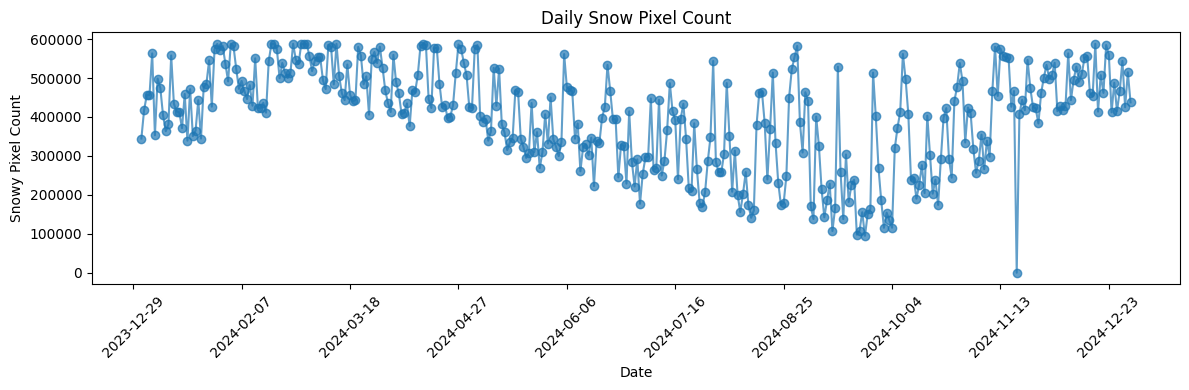

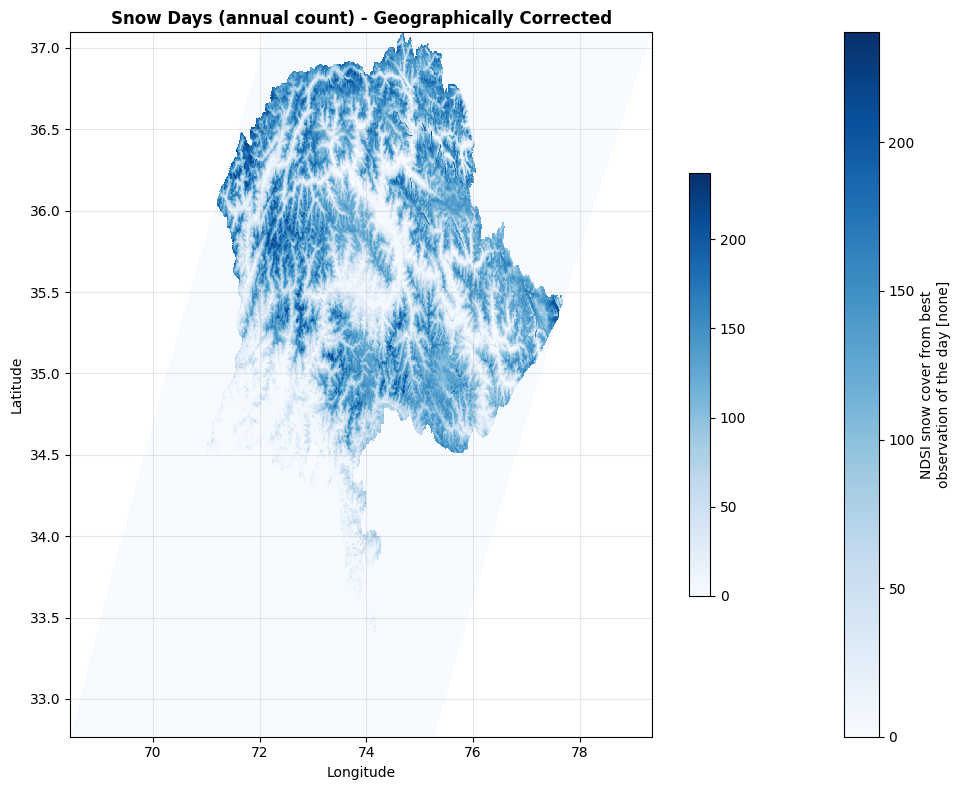

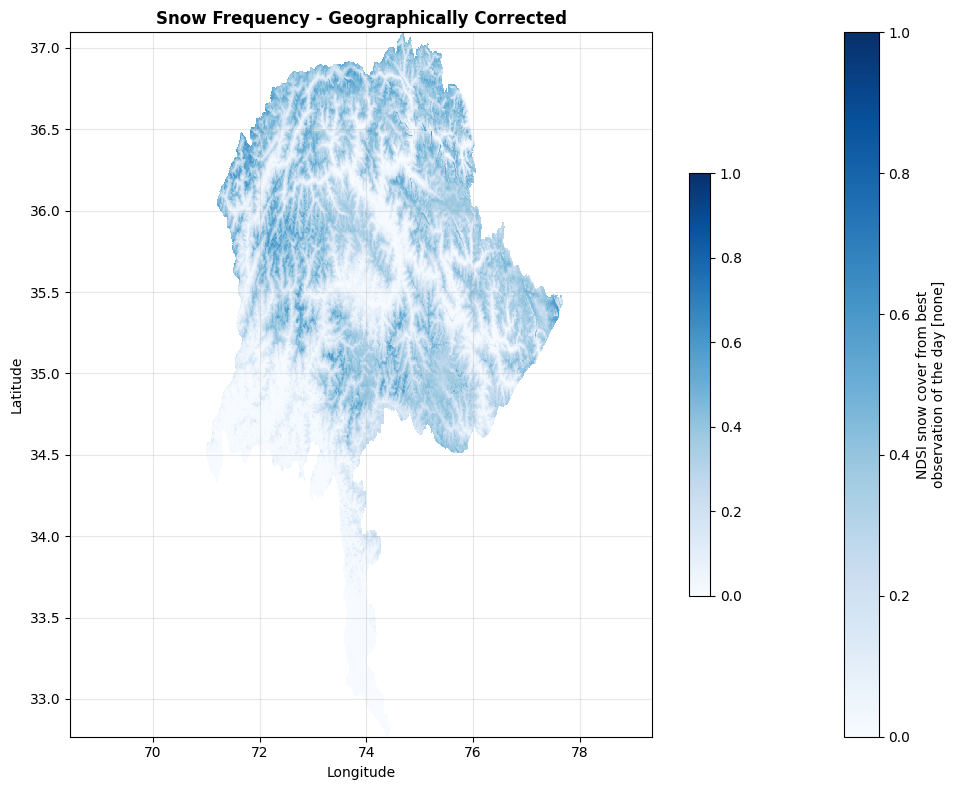

In [7]:
import matplotlib.pyplot as plt
from matplotlib import ticker

print('COG output folder:', output_cog_dir)
print('Summary output folder:', output_summary_dir)
print('Number of daily COGs:', len(list(output_cog_dir.glob('snow_*.tif'))))
print('Summary files:', sorted([p.name for p in output_summary_dir.glob('*')]))

if 'summary_stats' not in globals() or summary_stats is None:
    cog_paths = sorted(output_cog_dir.glob('snow_*.tif'))
    summary_stats = pd.DataFrame({
        'date': [pd.to_datetime(p.stem.split('_')[1], format='%Y%j') for p in cog_paths],
        'snowy_pixels': [
            (rioxarray.open_rasterio(str(p), masked=True).squeeze('band', drop=True) > 0).sum().item()
            for p in cog_paths
        ],
    })

print('Loaded summary_stats rows:', len(summary_stats))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(summary_stats['date'], summary_stats['snowy_pixels'], marker='o', linestyle='-', color='tab:blue', alpha=0.7)
ax.set_title('Daily Snow Pixel Count')
ax.set_xlabel('Date')
ax.set_ylabel('Snowy Pixel Count')
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def plot_raster(path, title, cmap='Blues', vmin=None, vmax=None):
    # Load and reproject to geographic CRS to fix distortion
    da = rioxarray.open_rasterio(str(path), masked=True).squeeze('band', drop=True)
    da_geo = da.rio.reproject('EPSG:4326', resolution=0.004)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = da_geo.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)
    fig.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout()
    plt.show()

plot_raster(output_summary_dir / 'snow_days.tif', 'Snow Days (annual count) - Geographically Corrected', cmap='Blues')
plot_raster(output_summary_dir / 'snow_frequency.tif', 'Snow Frequency - Geographically Corrected', cmap='Blues', vmin=0, vmax=1)

Snow summary metrics:
                min         max       mean   median
snow_days       0.0  237.000000  32.672945  0.00000
snow_frequency  0.0    0.649315   0.218418  0.22314


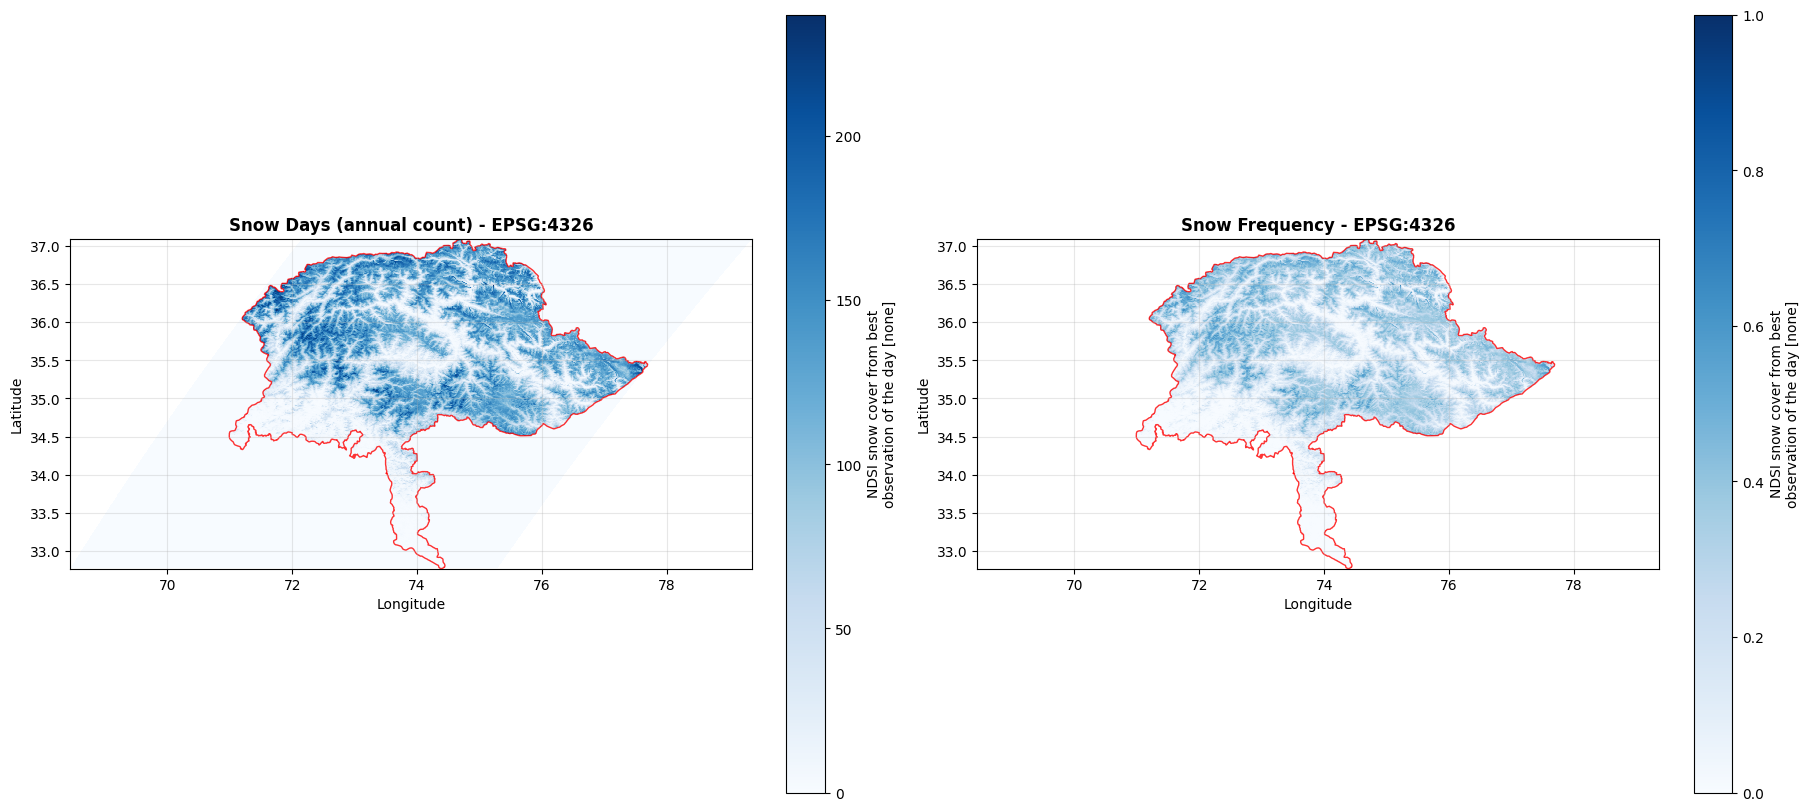


All plots now use EPSG:4326 projection for geographically accurate visualization.


In [8]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray

# Load rasters in original projection for metrics, then reproject for visualization
snow_days_orig = rioxarray.open_rasterio(str(output_summary_dir / 'snow_days.tif'), masked=True).squeeze('band', drop=True)
snow_freq_orig = rioxarray.open_rasterio(str(output_summary_dir / 'snow_frequency.tif'), masked=True).squeeze('band', drop=True)

snow_days_orig = snow_days_orig.where(snow_days_orig >= 0)
snow_freq_orig = snow_freq_orig.where((snow_freq_orig >= 0) & (snow_freq_orig <= 1))

# Reproject to geographic CRS for correct visualization
snow_days_geo = snow_days_orig.rio.reproject('EPSG:4326', resolution=0.004)
snow_freq_geo = snow_freq_orig.rio.reproject('EPSG:4326', resolution=0.004)

# Load boundary in geographic CRS
boundary_geo = gpd.read_file(aoi_path)
if boundary_geo.crs != 'EPSG:4326':
    boundary_geo = boundary_geo.to_crs('EPSG:4326')

metrics = {
    'snow_days': {
        'min': float(snow_days_orig.min().item()),
        'max': float(snow_days_orig.max().item()),
        'mean': float(snow_days_orig.mean().item()),
        'median': float(snow_days_orig.median().item()),
    },
    'snow_frequency': {
        'min': float(snow_freq_orig.min().item()),
        'max': float(snow_freq_orig.max().item()),
        'mean': float(snow_freq_orig.mean().item()),
        'median': float(snow_freq_orig.median().item()),
    },
}
print('Snow summary metrics:')
print(pd.DataFrame(metrics).T)

fig, axs = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# Plot reprojected data
snow_days_geo.plot(ax=axs[0], cmap='Blues', vmin=0, vmax=float(snow_days_geo.max().item()))
boundary_geo.plot(ax=axs[0], facecolor='none', edgecolor='red', linewidth=1, alpha=0.8)
axs[0].set_title('Snow Days (annual count) - EPSG:4326', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Latitude')
axs[0].grid(True, alpha=0.3)

snow_freq_geo.plot(ax=axs[1], cmap='Blues', vmin=0, vmax=1)
boundary_geo.plot(ax=axs[1], facecolor='none', edgecolor='red', linewidth=1, alpha=0.8)
axs[1].set_title('Snow Frequency - EPSG:4326', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Longitude')
axs[1].set_ylabel('Latitude')
axs[1].grid(True, alpha=0.3)

plt.show()

print('\nAll plots now use EPSG:4326 projection for geographically accurate visualization.')

=== Raster Projection Diagnostics ===
Snow Days CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: BoundingBox(left=6399275.240681585, bottom=3643954.5154910646, right=7039110.102206638, top=4124873.115247042)
Shape: 1038 x 1381
Pixel size: (463.3127165279169, 463.3127165279165)
Extent: 639835m x 480919m
Aspect ratio (w/h): 1.330

Original CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"

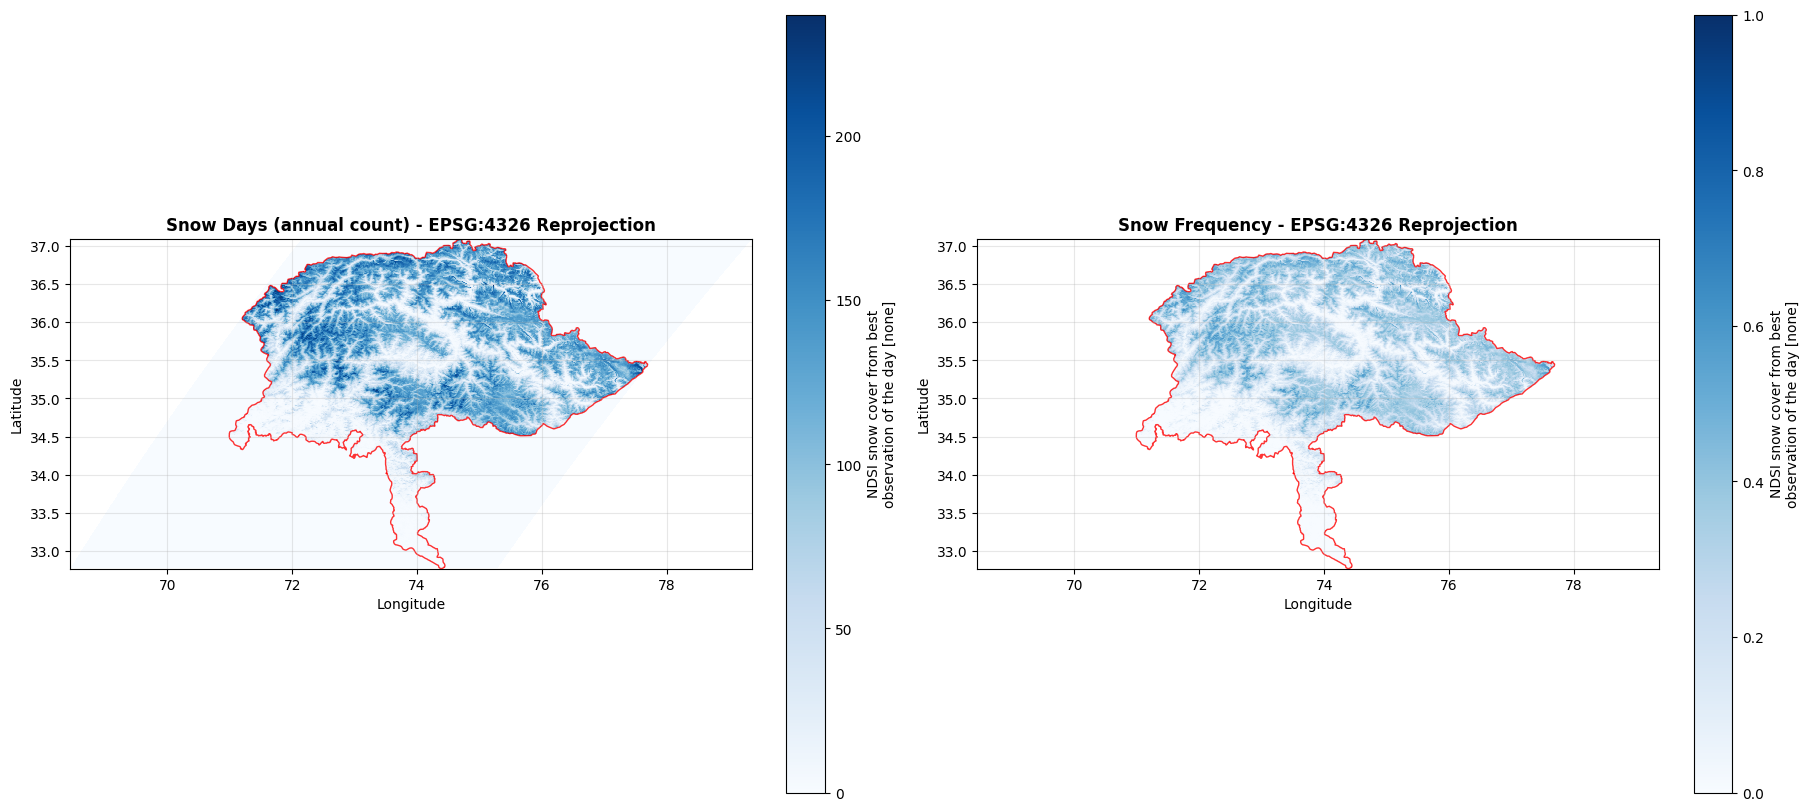


Reprojected plots displayed above - aspect ratio is now geographically accurate.
Red boundary shows the AOI extent in geographic coordinates.


In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray
import rasterio

# Diagnose projection and aspect ratio issues
print('=== Raster Projection Diagnostics ===')
with rasterio.open(str(output_summary_dir / 'snow_days.tif')) as src:
    print(f'Snow Days CRS: {src.crs}')
    print(f'Bounds: {src.bounds}')
    print(f'Shape: {src.height} x {src.width}')
    print(f'Pixel size: {src.res}')
    
    # Calculate actual extent in geographic coordinates
    bounds = src.bounds
    extent_width_m = bounds.right - bounds.left
    extent_height_m = bounds.top - bounds.bottom
    print(f'Extent: {extent_width_m:.0f}m x {extent_height_m:.0f}m')
    print(f'Aspect ratio (w/h): {extent_width_m / extent_height_m:.3f}')

# Load boundary in geographic CRS for reference
boundary_geo = gpd.read_file(aoi_path)
if boundary_geo.crs != 'EPSG:4326':
    boundary_geo = boundary_geo.to_crs('EPSG:4326')

# Load rasters and reproject to geographic CRS for clean visualization
snow_days_geo = rioxarray.open_rasterio(
    str(output_summary_dir / 'snow_days.tif'), 
    masked=True
).squeeze('band', drop=True)
snow_freq_geo = rioxarray.open_rasterio(
    str(output_summary_dir / 'snow_frequency.tif'), 
    masked=True
).squeeze('band', drop=True)

print(f'\nOriginal CRS: {snow_days_geo.rio.crs}')

# Reproject to geographic CRS (EPSG:4326) for correct visualization
snow_days_geo = snow_days_geo.rio.reproject('EPSG:4326', resolution=0.004)
snow_freq_geo = snow_freq_geo.rio.reproject('EPSG:4326', resolution=0.004)

print(f'Reprojected to: {snow_days_geo.rio.crs}')
print(f'New shape: {snow_days_geo.shape}')

# Clean data
snow_days_geo = snow_days_geo.where(snow_days_geo >= 0)
snow_freq_geo = snow_freq_geo.where((snow_freq_geo >= 0) & (snow_freq_geo <= 1))

# Plot reprojected data with geodetic context
fig, axs = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# Snow Days
im0 = snow_days_geo.plot(ax=axs[0], cmap='Blues', vmin=0, vmax=float(snow_days_geo.max().item()))
boundary_geo.plot(ax=axs[0], facecolor='none', edgecolor='red', linewidth=1, alpha=0.8)
axs[0].set_title('Snow Days (annual count) - EPSG:4326 Reprojection', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Latitude')
axs[0].grid(True, alpha=0.3)

# Snow Frequency
im1 = snow_freq_geo.plot(ax=axs[1], cmap='Blues', vmin=0, vmax=1)
boundary_geo.plot(ax=axs[1], facecolor='none', edgecolor='red', linewidth=1, alpha=0.8)
axs[1].set_title('Snow Frequency - EPSG:4326 Reprojection', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Longitude')
axs[1].set_ylabel('Latitude')
axs[1].grid(True, alpha=0.3)

plt.show()

print('\nReprojected plots displayed above - aspect ratio is now geographically accurate.')
print('Red boundary shows the AOI extent in geographic coordinates.')
